<a href="https://colab.research.google.com/github/aditya-singh-231/Demand-Forecasting-System/blob/main/demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tqdm joblib fastapi uvicorn nest-asyncio

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
GPU available: True


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving store-sales-time-series-forecasting.zip to store-sales-time-series-forecasting.zip


In [ ]:
import os
import zipfile

os.makedirs("/content/data", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/scalers", exist_ok=True)
os.makedirs("/content/artifacts", exist_ok=True)

zip_file = "/content/store-sales-time-series-forecasting.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print(os.listdir("/content/data"))

['sample_submission.csv', 'test.csv', 'oil.csv', 'stores.csv', 'train.csv', 'transactions.csv', 'holidays_events.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
import joblib
import random
import os

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [ ]:
train = pd.read_csv("/content/data/train.csv")
stores = pd.read_csv("/content/data/stores.csv")
oil = pd.read_csv("/content/data/oil.csv")
holidays = pd.read_csv("/content/data/holidays_events.csv")
transactions = pd.read_csv("/content/data/transactions.csv")

print("Train shape:", train.shape)

train.head()

Train shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:
print(train.info())

print("\nMissing values:")
print(train.isnull().sum())

print("\nDate range:")
print(train["date"].min())
print(train["date"].max())

print("\nNumber of products:")
print(train["family"].nunique())

print("\nNumber of stores:")
print(train["store_nbr"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
None

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Date range:
2013-01-01
2017-08-15

Number of products:
33

Number of stores:
54


In [ ]:
train["date"] = pd.to_datetime(train["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
transactions["date"] = pd.to_datetime(transactions["date"])

In [ ]:
df = train.merge(
    stores,
    on="store_nbr",
    how="left"
)

df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [ ]:
df = df.merge(
    oil,
    on="date",
    how="left"
)

print(df.shape)

(3000888, 11)


In [ ]:
df["dcoilwtico"] = df["dcoilwtico"].ffill().bfill()

print(df["dcoilwtico"].isnull().sum())

0


In [ ]:
df = df.merge(
    transactions,
    on=["date", "store_nbr"],
    how="left"
)

df["transactions"] = df["transactions"].fillna(0)

print(df.shape)

(3000888, 12)


In [ ]:
holiday_dates = holidays[
    holidays["type"].isin(["Holiday", "Additional", "Bridge", "Event"])
]["date"].unique()

df["is_holiday"] = df["date"].isin(holiday_dates).astype(int)

In [ ]:
df["is_holiday"] = df["date"].isin(holiday_dates).astype(int)

In [ ]:
df = df.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

print(df.shape)

(3000888, 13)


In [ ]:
series_list = (
    df[["store_nbr", "family"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Total series:", len(series_list))

Total series: 1782


In [ ]:
np.random.seed(42)

selected_series = series_list.sample(
    n=min(220, len(series_list)),
    random_state=42
)

df_4l = df.merge(
    selected_series,
    on=["store_nbr", "family"],
    how="inner"
)

print("Before limiting:", len(df_4l))

Before limiting: 370480


In [ ]:
df_4l = df_4l.sort_values("date").reset_index(drop=True)

if len(df_4l) > 400000:
    df_4l = df_4l.tail(400000)

print("Final dataset size:", len(df_4l))

Final dataset size: 370480


In [ ]:
df_4l["year"] = df_4l["date"].dt.year
df_4l["month"] = df_4l["date"].dt.month
df_4l["day"] = df_4l["date"].dt.day

df_4l["day_of_week"] = df_4l["date"].dt.dayofweek

df_4l["is_weekend"] = (
    df_4l["day_of_week"] >= 5
).astype(int)

df_4l["quarter"] = df_4l["date"].dt.quarter

df_4l["day_of_year"] = df_4l["date"].dt.dayofyear

df_4l["week_of_year"] = (
    df_4l["date"].dt.isocalendar().week.astype(int)
)

In [ ]:
group_cols = ["store_nbr", "family"]

df_4l = df_4l.sort_values(
    group_cols + ["date"]
)

for lag in [1, 7, 14, 28]:

    df_4l[f"lag_{lag}"] = (
        df_4l.groupby(group_cols)["sales"]
        .shift(lag)
    )

In [ ]:
for window in [7, 14, 28]:

    df_4l[f"rolling_mean_{window}"] = (
        df_4l.groupby(group_cols)["sales"]
        .transform(
            lambda x: x.shift(1).rolling(window).mean()
        )
    )

In [ ]:
for window in [7, 14]:

    df_4l[f"rolling_std_{window}"] = (
        df_4l.groupby(group_cols)["sales"]
        .transform(
            lambda x: x.shift(1).rolling(window).std()
        )
    )

In [ ]:
df_4l["month_sin"] = np.sin(
    2 * np.pi * df_4l["month"] / 12
)

df_4l["month_cos"] = np.cos(
    2 * np.pi * df_4l["month"] / 12
)

df_4l["dow_sin"] = np.sin(
    2 * np.pi * df_4l["day_of_week"] / 7
)

df_4l["dow_cos"] = np.cos(
    2 * np.pi * df_4l["day_of_week"] / 7
)

In [ ]:
family_encoder = LabelEncoder()
city_encoder = LabelEncoder()
state_encoder = LabelEncoder()
type_encoder = LabelEncoder()
cluster_encoder = LabelEncoder()

df_4l["family_encoded"] = family_encoder.fit_transform(
    df_4l["family"]
)

df_4l["city_encoded"] = city_encoder.fit_transform(
    df_4l["city"]
)

df_4l["state_encoded"] = state_encoder.fit_transform(
    df_4l["state"]
)

df_4l["type_encoded"] = type_encoder.fit_transform(
    df_4l["type"]
)

In [ ]:
df_4l["cluster_encoded"] = cluster_encoder.fit_transform(
    df_4l["cluster"].astype(str)
)

In [ ]:
print("Before dropping NA:", df_4l.shape)

df_4l = df_4l.dropna().reset_index(drop=True)

print("After dropping NA:", df_4l.shape)

Before dropping NA: (370480, 39)
After dropping NA: (364320, 39)


In [ ]:
if len(df_4l) > 400000:
    df_4l = df_4l.tail(400000).copy()

print("Final observations:", len(df_4l))

Final observations: 364320


In [ ]:
feature_cols = [

    # Demand history
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",

    # Rolling features
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_14",

    # Calendar
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",

    "is_weekend",
    "quarter",

    # External
    "onpromotion",
    "dcoilwtico",
    "transactions",
    "is_holiday",

    # Categorical
    "store_nbr",
    "family_encoded",
    "city_encoded",
    "state_encoded",
    "type_encoded",
    "cluster_encoded"
]

target_col = "sales"

print("Number of features:", len(feature_cols))

Number of features: 25


In [ ]:
unique_dates = np.sort(
    df_4l["date"].unique()
)

n_dates = len(unique_dates)

train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = df_4l[
    df_4l["date"].isin(train_dates)
].copy()

val_df = df_4l[
    df_4l["date"].isin(val_dates)
].copy()

test_df = df_4l[
    df_4l["date"].isin(test_dates)
].copy()

In [ ]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain dates:")
print(train_df["date"].min(), train_df["date"].max())

print("\nValidation dates:")
print(val_df["date"].min(), val_df["date"].max())

print("\nTest dates:")
print(test_df["date"].min(), test_df["date"].max())

Train: 254980
Validation: 54560
Test: 54780

Train dates:
2013-01-29 00:00:00 2016-04-04 00:00:00

Validation dates:
2016-04-05 00:00:00 2016-12-08 00:00:00

Test dates:
2016-12-09 00:00:00 2017-08-15 00:00:00


In [ ]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train = feature_scaler.fit_transform(
    train_df[feature_cols]
)

X_val = feature_scaler.transform(
    val_df[feature_cols]
)

X_test = feature_scaler.transform(
    test_df[feature_cols]
)

y_train = target_scaler.fit_transform(
    train_df[[target_col]]
).flatten()

y_val = target_scaler.transform(
    val_df[[target_col]]
).flatten()

y_test = target_scaler.transform(
    test_df[[target_col]]
).flatten()

In [ ]:
joblib.dump(
    feature_scaler,
    "/content/scalers/feature_scaler.pkl"
)

joblib.dump(
    target_scaler,
    "/content/scalers/target_scaler.pkl"
)

['/content/scalers/target_scaler.pkl']

In [ ]:
class TimeSeriesDataset(Dataset):

    def __init__(
        self,
        df,
        feature_cols,
        feature_scaler,
        target_scaler,
        sequence_length=30
    ):

        self.X = []
        self.y = []

        df = df.copy()

        df = df.sort_values(
            ["store_nbr", "family", "date"]
        )

        for _, group in df.groupby(
            ["store_nbr", "family"]
        ):

            group = group.sort_values("date")

            if len(group) <= sequence_length:
                continue

            features = feature_scaler.transform(
                group[feature_cols]
            )

            target = target_scaler.transform(
                group[["sales"]]
            ).flatten()

            for i in range(
                sequence_length,
                len(group)
            ):

                self.X.append(
                    features[i-sequence_length:i]
                )

                self.y.append(
                    target[i]
                )

        self.X = np.array(
            self.X,
            dtype=np.float32
        )

        self.y = np.array(
            self.y,
            dtype=np.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            torch.tensor(self.X[idx]),
            torch.tensor(self.y[idx])
        )

In [ ]:
SEQUENCE_LENGTH = 30

train_dataset = TimeSeriesDataset(
    train_df,
    feature_cols,
    feature_scaler,
    target_scaler,
    SEQUENCE_LENGTH
)

val_dataset = TimeSeriesDataset(
    val_df,
    feature_cols,
    feature_scaler,
    target_scaler,
    SEQUENCE_LENGTH
)

test_dataset = TimeSeriesDataset(
    test_df,
    feature_cols,
    feature_scaler,
    target_scaler,
    SEQUENCE_LENGTH
)

In [ ]:
print("Train sequences:", len(train_dataset))
print("Validation sequences:", len(val_dataset))
print("Test sequences:", len(test_dataset))

Train sequences: 248380
Validation sequences: 47960
Test sequences: 48180


In [ ]:
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class LSTMForecastModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        last_hidden = lstm_out[:, -1, :]

        output = self.fc(last_hidden)

        return output.squeeze(1)

In [ ]:
INPUT_SIZE = len(feature_cols)

lstm_model = LSTMForecastModel(
    input_size=INPUT_SIZE
).to(DEVICE)

print(lstm_model)

LSTMForecastModel(
  (lstm): LSTM(25, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=500
    ):

        super().__init__()

        position = torch.arange(
            max_len
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            ) *
            (-np.log(10000.0) / d_model)
        )

        pe = torch.zeros(
            max_len,
            d_model
        )

        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

In [ ]:
class TransformerForecastModel(nn.Module):

    def __init__(
        self,
        input_size,
        d_model=128,
        nhead=8,
        num_layers=3,
        dropout=0.2
    ):

        super().__init__()

        self.input_projection = nn.Linear(
            input_size,
            d_model
        )

        self.positional_encoding = PositionalEncoding(
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):

        x = self.input_projection(x)

        x = self.positional_encoding(x)

        x = self.transformer(x)

        x = x[:, -1, :]

        output = self.fc(x)

        return output.squeeze(1)

In [ ]:
transformer_model = TransformerForecastModel(
    input_size=INPUT_SIZE
).to(DEVICE)

print(transformer_model)

TransformerForecastModel(
  (input_projection): Linear(in_features=25, out_features=128, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): 

In [ ]:
def calculate_metrics(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mask = y_true != 0

    mape = np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask])
            /
            y_true[mask]
        )
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    learning_rate=0.001,
    model_name="model"
):

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=3,
        factor=0.5
    )

    best_val_loss = float("inf")

    history = {
        "train_loss": [],
        "val_loss": []
    }

    patience_counter = 0
    early_stop_patience = 5

    for epoch in range(epochs):

        # TRAIN
        model.train()

        train_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            train_loss += (
                loss.item()
                *
                X_batch.size(0)
            )

        train_loss /= len(
            train_loader.dataset
        )

        # VALIDATION
        model.eval()

        val_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                predictions = model(X_batch)

                loss = criterion(
                    predictions,
                    y_batch
                )

                val_loss += (
                    loss.item()
                    *
                    X_batch.size(0)
                )

        val_loss /= len(
            val_loader.dataset
        )

        scheduler.step(val_loss)

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

        # SAVE BEST MODEL
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            patience_counter = 0

            torch.save(
                model.state_dict(),
                f"/content/models/{model_name}.pth"
            )

        else:

            patience_counter += 1

            if patience_counter >= early_stop_patience:

                print("Early stopping triggered")

                break

    return history

In [ ]:
lstm_model = LSTMForecastModel(
    input_size=INPUT_SIZE,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
).to(DEVICE)

lstm_history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    epochs=20,
    learning_rate=0.001,
    model_name="lstm_model"
)

Epoch 1/20 | Train Loss: 0.088195 | Val Loss: 0.241818
Epoch 2/20 | Train Loss: 0.060180 | Val Loss: 0.198152
Epoch 3/20 | Train Loss: 0.053759 | Val Loss: 0.195393
Epoch 4/20 | Train Loss: 0.050707 | Val Loss: 0.196037
Epoch 5/20 | Train Loss: 0.048972 | Val Loss: 0.215346
Epoch 6/20 | Train Loss: 0.047816 | Val Loss: 0.187774
Epoch 7/20 | Train Loss: 0.045678 | Val Loss: 0.191254
Epoch 8/20 | Train Loss: 0.042782 | Val Loss: 0.190076
Epoch 9/20 | Train Loss: 0.040504 | Val Loss: 0.187901
Epoch 10/20 | Train Loss: 0.040345 | Val Loss: 0.197764
Epoch 11/20 | Train Loss: 0.034257 | Val Loss: 0.188126
Early stopping triggered


In [ ]:
transformer_model = TransformerForecastModel(
    input_size=INPUT_SIZE,
    d_model=128,
    nhead=8,
    num_layers=3,
    dropout=0.2
).to(DEVICE)

transformer_history = train_model(
    transformer_model,
    train_loader,
    val_loader,
    epochs=20,
    learning_rate=0.0005,
    model_name="transformer_model"
)

Epoch 1/20 | Train Loss: 0.104019 | Val Loss: 0.261060
Epoch 2/20 | Train Loss: 0.069149 | Val Loss: 0.236802
Epoch 3/20 | Train Loss: 0.061428 | Val Loss: 0.196621
Epoch 4/20 | Train Loss: 0.056072 | Val Loss: 0.213833
Epoch 5/20 | Train Loss: 0.053478 | Val Loss: 0.222345
Epoch 6/20 | Train Loss: 0.050872 | Val Loss: 0.213289
Epoch 7/20 | Train Loss: 0.048854 | Val Loss: 0.203933
Epoch 8/20 | Train Loss: 0.040376 | Val Loss: 0.191658
Epoch 9/20 | Train Loss: 0.037590 | Val Loss: 0.183556
Epoch 10/20 | Train Loss: 0.036118 | Val Loss: 0.184079
Epoch 11/20 | Train Loss: 0.034448 | Val Loss: 0.227514
Epoch 12/20 | Train Loss: 0.034247 | Val Loss: 0.195570
Epoch 13/20 | Train Loss: 0.033389 | Val Loss: 0.202164
Epoch 14/20 | Train Loss: 0.029966 | Val Loss: 0.198535
Early stopping triggered


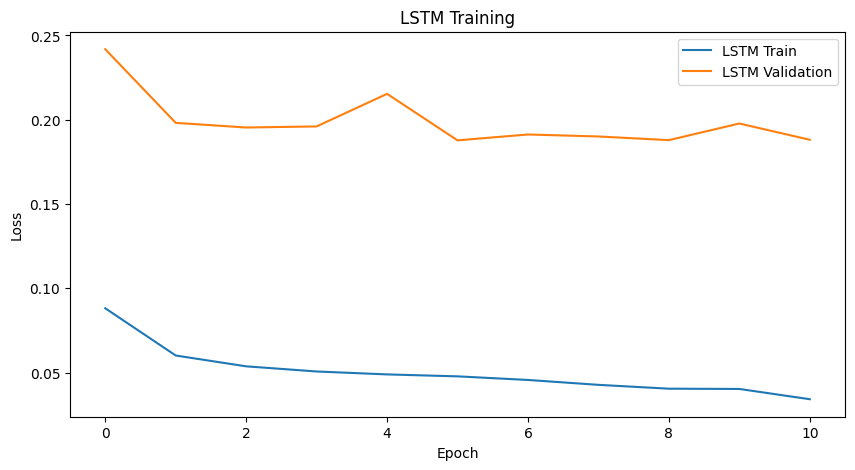

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history["train_loss"],
    label="LSTM Train"
)

plt.plot(
    lstm_history["val_loss"],
    label="LSTM Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("LSTM Training")

plt.legend()

plt.show()

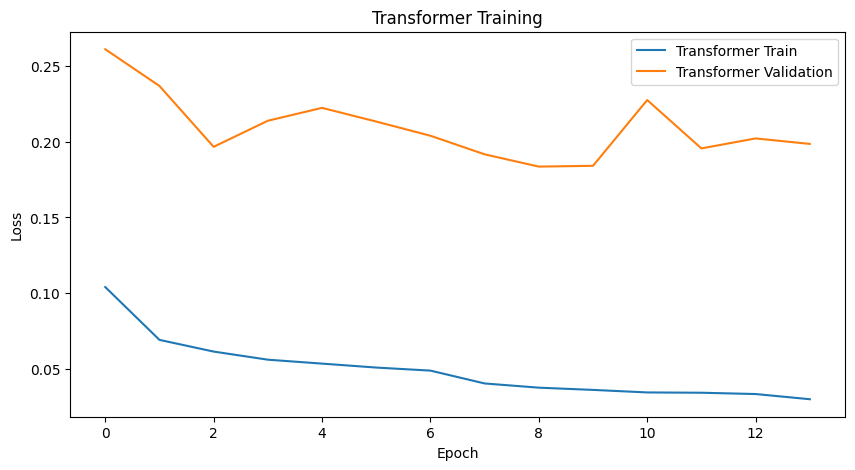

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    transformer_history["train_loss"],
    label="Transformer Train"
)

plt.plot(
    transformer_history["val_loss"],
    label="Transformer Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Transformer Training")

plt.legend()

plt.show()

In [ ]:
def evaluate_model(
    model,
    data_loader,
    target_scaler
):

    model.eval()

    predictions_list = []
    actual_list = []

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(DEVICE)

            predictions = model(X_batch)

            predictions_list.extend(
                predictions.cpu().numpy()
            )

            actual_list.extend(
                y_batch.numpy()
            )

    predictions = np.array(
        predictions_list
    ).reshape(-1, 1)

    actual = np.array(
        actual_list
    ).reshape(-1, 1)

    predictions = target_scaler.inverse_transform(
        predictions
    ).flatten()

    actual = target_scaler.inverse_transform(
        actual
    ).flatten()

    metrics = calculate_metrics(
        actual,
        predictions
    )

    return actual, predictions, metrics

In [ ]:
lstm_model.load_state_dict(
    torch.load(
        "/content/models/lstm_model.pth",
        map_location=DEVICE
    )
)

lstm_actual, lstm_predictions, lstm_metrics = (
    evaluate_model(
        lstm_model,
        test_loader,
        target_scaler
    )
)

print("LSTM Results")

for key, value in lstm_metrics.items():
    print(
        f"{key}: {value:.4f}"
    )

LSTM Results
MAE: 73.6082
RMSE: 289.8231
MAPE: 9134329.0000


In [ ]:
transformer_model.load_state_dict(
    torch.load(
        "/content/models/transformer_model.pth",
        map_location=DEVICE
    )
)

transformer_actual, transformer_predictions, transformer_metrics = (
    evaluate_model(
        transformer_model,
        test_loader,
        target_scaler
    )
)

print("Transformer Results")

for key, value in transformer_metrics.items():
    print(
        f"{key}: {value:.4f}"
    )

Transformer Results
MAE: 84.4876
RMSE: 261.8603
MAPE: 29030976.0000


In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "LSTM",
        **lstm_metrics
    },
    {
        "Model": "Transformer",
        **transformer_metrics
    }
])

comparison

,Model,MAE,RMSE,MAPE
0,LSTM,73.608223,289.823141,9134329.0
1,Transformer,84.487633,261.860277,29030976.0


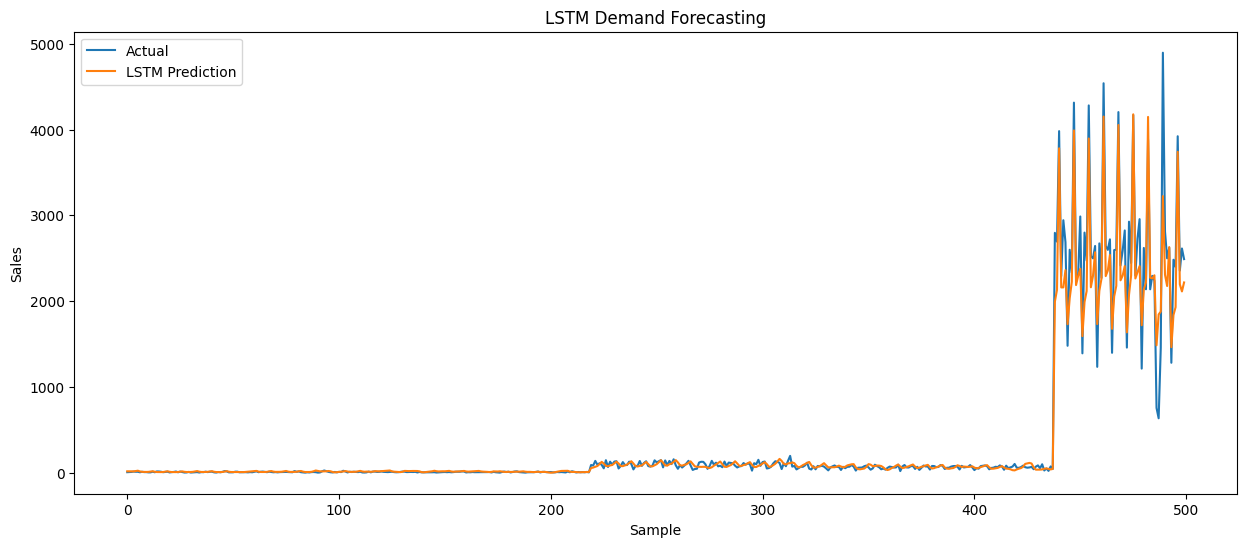

In [ ]:
n = 500

plt.figure(figsize=(15, 6))

plt.plot(
    lstm_actual[:n],
    label="Actual"
)

plt.plot(
    lstm_predictions[:n],
    label="LSTM Prediction"
)

plt.title("LSTM Demand Forecasting")

plt.xlabel("Sample")

plt.ylabel("Sales")

plt.legend()

plt.show()

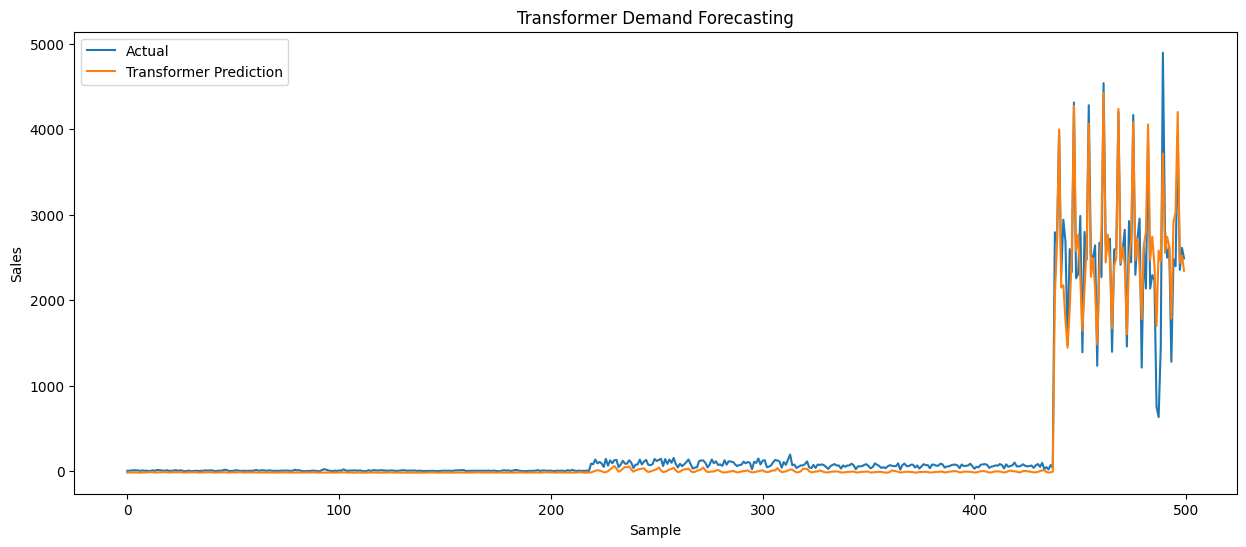

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    transformer_actual[:n],
    label="Actual"
)

plt.plot(
    transformer_predictions[:n],
    label="Transformer Prediction"
)

plt.title("Transformer Demand Forecasting")

plt.xlabel("Sample")

plt.ylabel("Sales")

plt.legend()

plt.show()